# 01: 動画 → 一次元輝度分布の抽出（低解像度・3チャンバー同時撮影系）

対流観察動画（MP4）から、各チャンバーの一次元輝度分布 L(x, t) を抽出してCSVに保存するノートブック。

**処理の流れ**
1. ffmpeg で動画から5秒間隔のフレームを抽出（§1）
2. 90°回転＋グレースケール化（サンプルによっては微小回転補正・画像レベル背景除去）（§2）
3. キャリブレーション線・抽出線の目視確認（§3）
4. 底面から柱高さの1/2上（水深10 mmに対して7.5 mm相当）の水平線上で輝度を抽出し、チャンバーごとにCSV保存（§4）

**使い方**
1. 「パス設定」セルで `RAW_VIDEO_ROOT` を自分の環境に合わせて書き換える
2. `SAMPLE_ID` を `../config/samples_lowres.json` のキーから1つ選ぶ
3. Run All

**前提**: ffmpeg がPATHに通っていること（READMEのセットアップ手順を参照）。
サンプル別のキャリブレーション座標・条件・旧ファイル名との対応は、すべて `config/samples_lowres.json` に記録されている。

## セットアップ

In [1]:
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from PIL import Image, ImageOps
from IPython.display import display

In [2]:
# ============ パス設定（環境に合わせて書き換える） ============

# 生動画の置き場所。{date}/ 以下に動画ファイルがある構成を想定
#   例: RAW_VIDEO_ROOT/251117/149A3606.MP4
RAW_VIDEO_ROOT = Path("D:/kyoto_univ/raw_videos")          # ★要変更

FRAMES_ROOT = Path("D:/kyoto_univ/tempdata/frames_lowres")      # 抽出フレームの一時置き場（サイズ大・git管理外）
OUTPUT_ROOT = Path("../data/luminance_1d")       # 一次元輝度分布CSVの出力先
CONFIG_PATH = Path("../config/samples_lowres.json")

# ============ サンプル選択 ============
SAMPLE_ID = "250320_149A3445"                    # ★処理したいサンプルをconfigのキーから選ぶ

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = json.load(f)

print("利用可能なサンプル:")
for k, v in config["samples"].items():
    mark = " (TODO: 座標未転記)" if v["chambers"] is None else ""
    print(f"  {k}{mark}")

cfg = config["samples"][SAMPLE_ID]
defaults = config["defaults"]
assert cfg["chambers"] is not None, f"{SAMPLE_ID} は座標未転記のプレースホルダです"

print(f"\n選択中: {SAMPLE_ID}")
print(json.dumps({c: v["condition"] for c, v in cfg["chambers"].items()},
                 ensure_ascii=False, indent=2))

利用可能なサンプル:
  250320_149A3445
  250320_149A3444
  250320_149A3447
  250320_149A3449
  250320_149A3446
  250320_149A3448
  250617_149A3477
  250617_149A3478
  250617_149A3479
  250617_149A3480
  250617_149A3481
  250619_149A3487
  250619_149A3490
  250619_149A3491
  250807_149A3578
  251117_149A3606
  251117_149A3607
  251117_149A3608
  251208_149A3642
  251208_149A3639
  251208_149A3653
  250807_149A3575
  250807_149A3576
  250807_149A3577

選択中: 250320_149A3445
{
  "top": "(0,0,0)",
  "middle": "(0,0,0)",
  "bottom": "(0,0,0)"
}


## 関数群

※ ノートブック完結型の方針のため、共通関数は 01 / 02 の各ノートブック冒頭に同一のコピーを持つ。
**修正する場合は必ず両方を同時に修正すること**（README参照）。

In [3]:
def parse_sec(path: Path) -> int:
    """フレームファイル名 'frame_{sec}sec_*.png' から秒数を取り出す。"""
    name = path.name
    return int(name.split("_")[1].replace("sec", ""))


def extract_frames_ffmpeg(video_path: Path, frames_dir: Path,
                          fps: int, time_period: int, start_sec: int, end_sec: int) -> None:
    """動画から time_period 秒間隔で1フレームずつPNGを抽出する。

    旧コードは各時刻で2フレーム(-vframes 2)を抽出し、後段で1枚おきに間引いて
    各時刻の1枚目のみを使っていた。ここでは等価な処理として最初から1枚のみ抽出する。
    """
    frames_dir.mkdir(parents=True, exist_ok=True)
    for start_time in range(start_sec, end_sec, time_period):
        output_path = frames_dir / f"frame_{start_time}sec_%2d.png"
        cmd = [
            "ffmpeg",
            "-ss", str(start_time),   # 先にシークして高速化
            "-i", str(video_path),
            "-vf", f"fps={fps}",
            "-vframes", "1",
            "-vsync", "vfr",          # 不要なフレームの生成を防ぐ
            str(output_path),
        ]
        subprocess.run(cmd, capture_output=True, text=True)


def load_grayscale_frames(frames_dir: Path, base_rotation_deg: int = 90,
                          fine_rotation_deg: float = 0.0) -> list:
    """フレームPNGを時系列順に読み込み、回転＋グレースケール化して返す。

    旧コードは os.listdir の返却順（環境依存）に頼っていたが、
    ここではファイル名の秒数で明示的に数値ソートし、時系列順を保証する。
    """
    paths = sorted(frames_dir.glob("*.png"), key=parse_sec)
    images = []
    for p in paths:
        img = Image.open(p)
        img = img.rotate(base_rotation_deg, expand=True)
        if fine_rotation_deg:
            img = img.rotate(fine_rotation_deg, expand=True)  # 例: -1 は旧コードの rotate(359) と等価
        images.append(ImageOps.grayscale(img))
    return images


def remove_background_min(images: list) -> list:
    """画像レベル背景除去（0320ロット互換）: 各画素の時系列最小値を背景として減算する。

    省メモリ実装: 全フレームを一括スタックせず、(1)背景の逐次min計算、
    (2)1枚ずつの減算、の2パスで処理する。背景は画素ごとの最小値なので
    減算は決して負にならず、クリップ処理は不要（旧実装のclipと等価）。
    """
    bg = np.array(images[0], dtype=np.uint8)
    for img in images[1:]:
        np.minimum(bg, np.array(img), out=bg)
    for i in range(len(images)):
        arr = np.array(images[i])
        images[i] = Image.fromarray(arr - bg)
    return images


def show_line_overlay(img, line_position, title=""):
    """画像に線分 [x1, y1, x2, y2] を重ねて表示する（キャリブレーション確認用）。"""
    plt.imshow(img, cmap="gray")
    plt.grid(True)
    plt.axis("on")
    line = mlines.Line2D([line_position[0], line_position[2]],
                         [line_position[1], line_position[3]],
                         linewidth=2, color="r")
    plt.gca().add_line(line)
    if title:
        plt.title(title)


def extract_luminance_from_line(grayscale_images, line_segment):
    """画像リストから指定した水平線分 (x1, y1, x2, y2) 上の輝度値を抽出する。

    Parameters
    ----------
    grayscale_images : list of PIL.Image
        グレースケール画像の時系列リスト
    line_segment : list or tuple
        (x1, y1, x2, y2)

    Returns
    -------
    list of list
        各時刻の一次元輝度分布 L(x)
    """
    extracted_luminance = []
    for img in grayscale_images:
        img_array = np.array(img)
        x1, y1, x2, y2 = (round(v) for v in line_segment)
        extracted_luminance.append(img_array[y1, x1:x2 + 1].tolist())
    return extracted_luminance

## §1 フレーム抽出

動画から5秒間隔でフレームを抽出する。既に抽出済み（フォルダが存在する）の場合はスキップする。

In [19]:
video_path = RAW_VIDEO_ROOT / cfg["date"] / cfg["video_file"]
frames_dir = FRAMES_ROOT / SAMPLE_ID

if frames_dir.exists():
    print(f"Skip: フレームフォルダが既に存在します -> {frames_dir}")
else:
    assert video_path.exists(), f"動画が見つかりません: {video_path}"
    extract_frames_ffmpeg(
        video_path, frames_dir,
        fps=defaults["fps"], time_period=defaults["time_period_sec"],
        start_sec=defaults["start_sec"], end_sec=defaults["end_sec"],
    )
    print(f"抽出完了 -> {frames_dir}")

print(f"フレーム数: {len(list(frames_dir.glob('*.png')))}")

抽出完了 -> D:\kyoto_univ\tempdata\frames_lowres\250320_149A3445
フレーム数: 360


## §2 前処理（回転・グレースケール化）

90°回転＋グレースケール化を行う。configで指定がある場合のみ、微小回転補正（例: 251117_149A3608 の -1°）
および画像レベル背景除去（0320ロットのみ）を適用する。

読み込み画像数: 360（5秒間隔・時系列順）
画像レベル背景除去を適用します（0320ロット互換）


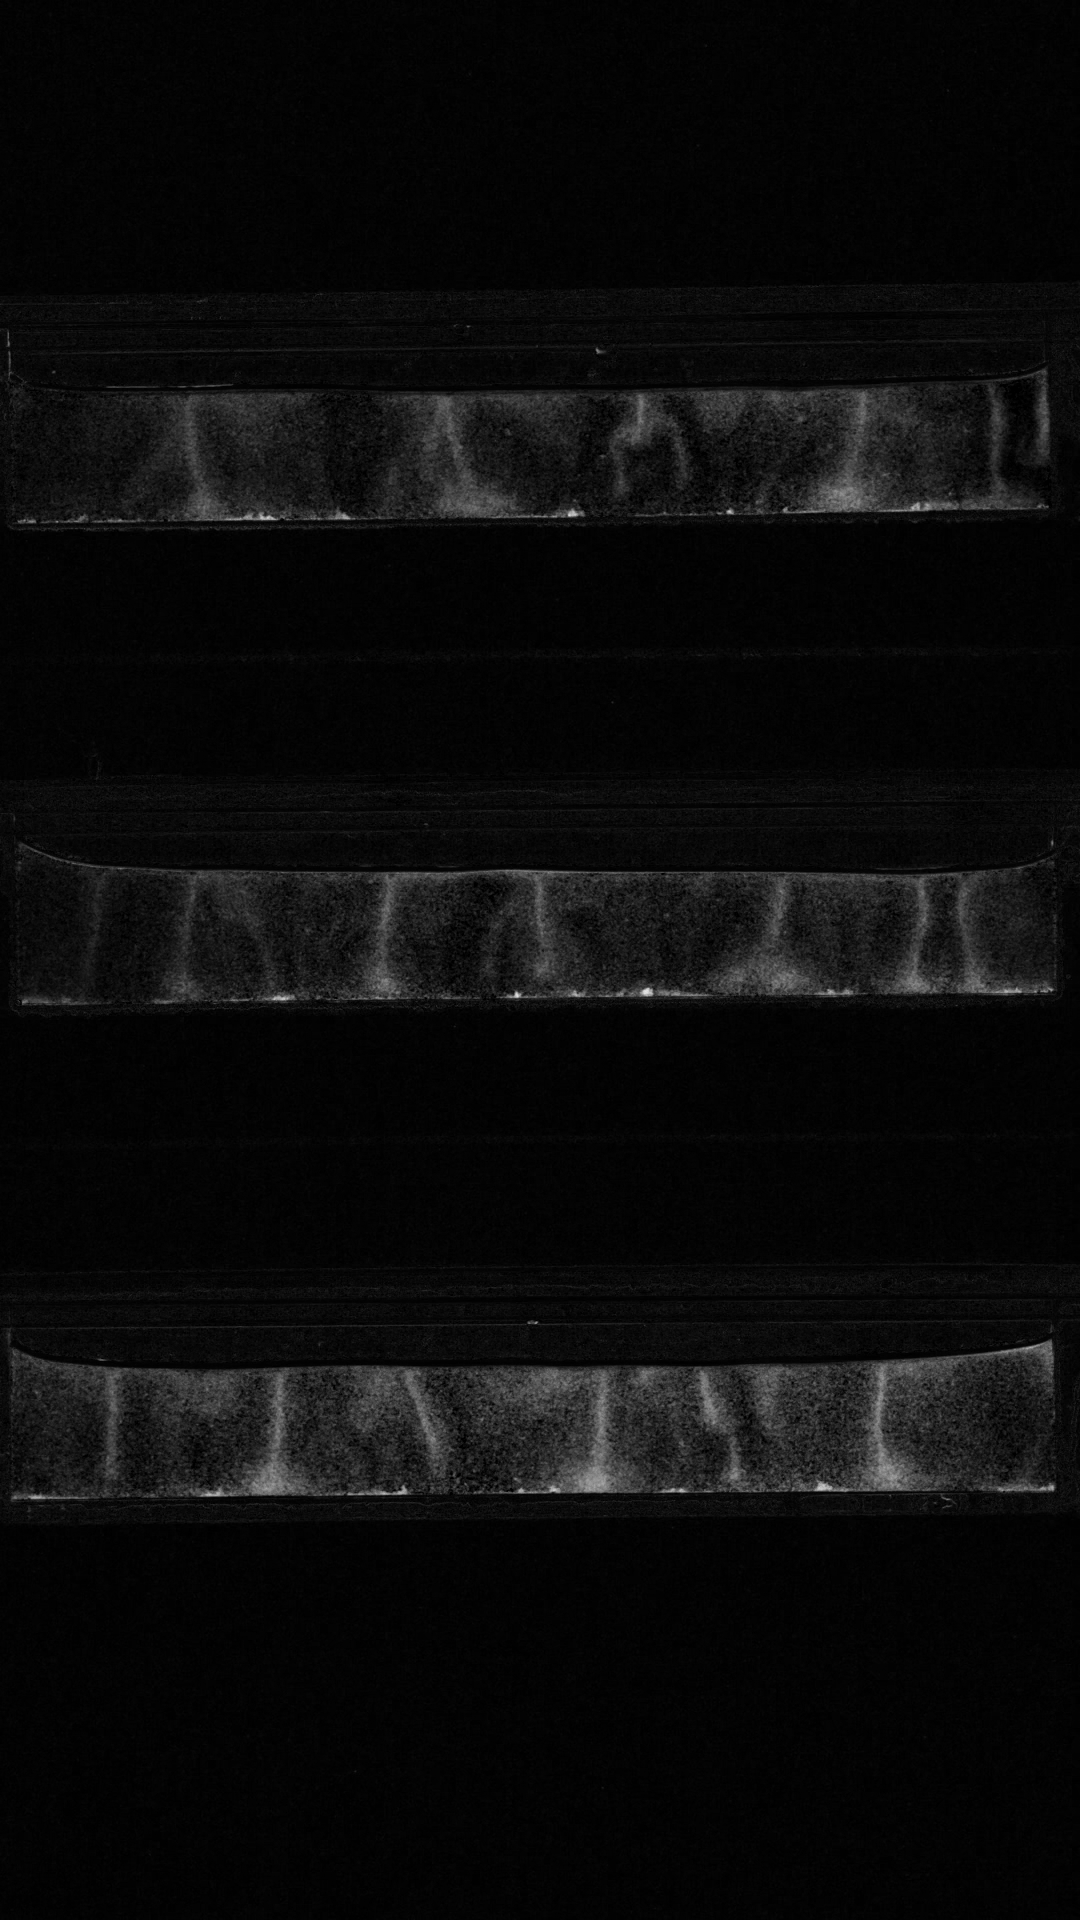

In [21]:
images = load_grayscale_frames(
    frames_dir,
    base_rotation_deg=defaults["base_rotation_deg"],
    fine_rotation_deg=cfg["fine_rotation_deg"],
)
print(f"読み込み画像数: {len(images)}（5秒間隔・時系列順）")

if cfg["image_level_bg_removal"]:
    print("画像レベル背景除去を適用します（0320ロット互換）")
    images = remove_background_min(images)

display(images[-1])

## §3 キャリブレーション確認

上段: 柱高さ（基準5 mm）に合わせた較正線。px/mm換算の根拠となる。
下段: 一次元輝度分布 L(x) の抽出線（較正線上端から柱高さの1/2上 ＝ 底面から7.5 mm相当）。
いずれの座標も `config/samples_lowres.json` に記録された手動指定値であり、赤線が意図した位置に
重なっていることを目視で確認する。

[top] 較正線長 = 60 px (-> 12.0 px/mm 基準)
[middle] 較正線長 = 62 px (-> 12.4 px/mm 基準)
[bottom] 較正線長 = 60 px (-> 12.0 px/mm 基準)


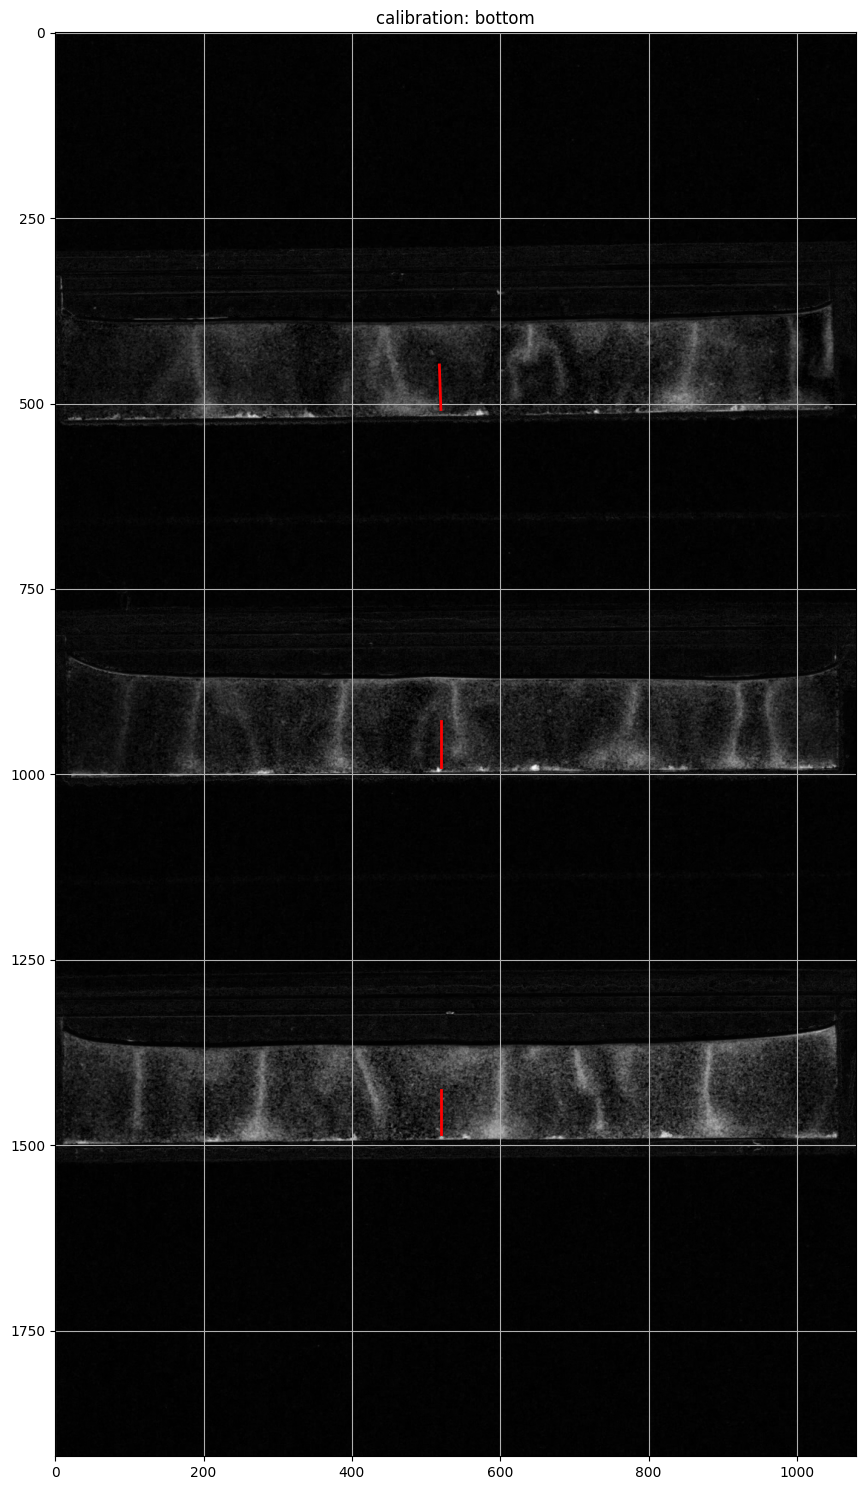

In [22]:
CHAMBERS = ["top", "middle", "bottom"]

plt.figure(figsize=(20, 15))
for ch in CHAMBERS:
    cal = cfg["chambers"][ch]["calibration_line_px"]
    show_line_overlay(images[-1], cal, title=f"calibration: {ch}")
    h_px = cal[3] - cal[1]
    print(f"[{ch}] 較正線長 = {h_px} px "
          f"(-> {h_px / defaults['pillar_height_mm_for_calibration']:.1f} px/mm 基準)")
plt.tight_layout()
plt.show()

[top] 抽出線: y = 418 px, 幅 = 1024 px (チャンバー幅80 mm相当)
[middle] 抽出線: y = 898 px, 幅 = 1024 px (チャンバー幅80 mm相当)
[bottom] 抽出線: y = 1395 px, 幅 = 1030 px (チャンバー幅80 mm相当)


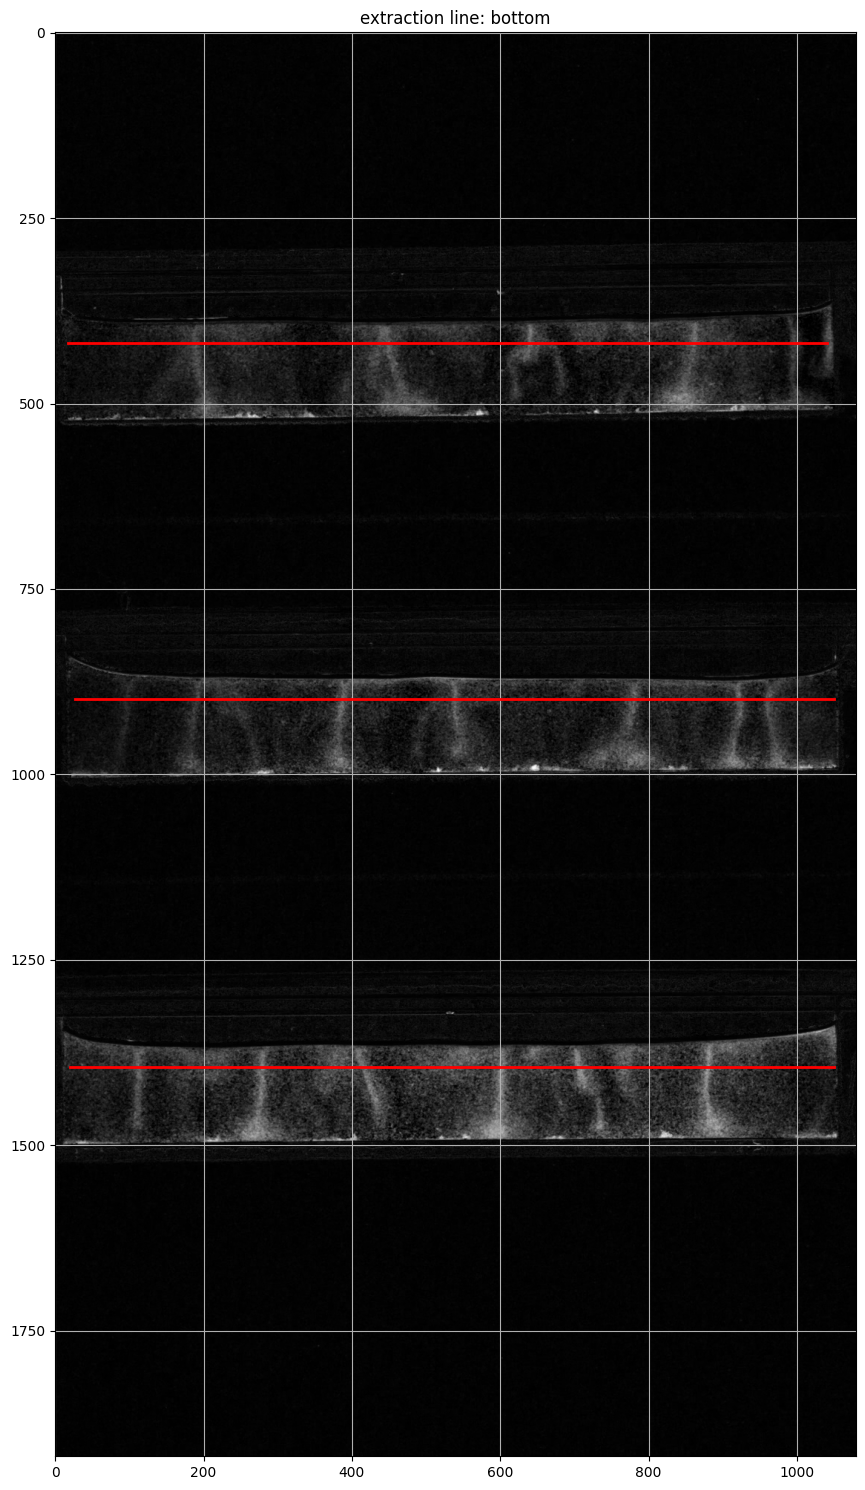

In [23]:
plt.figure(figsize=(20, 15))
for ch in CHAMBERS:
    ext = cfg["chambers"][ch]["extraction_line_px"]
    show_line_overlay(images[-1], ext, title=f"extraction line: {ch}")
    print(f"[{ch}] 抽出線: y = {ext[1]} px, 幅 = {ext[2] - ext[0]} px (チャンバー幅80 mm相当)")
plt.tight_layout()
plt.show()

## §4 一次元輝度分布の抽出・保存

チャンバーごとに `lumi1d_{date}_{video}_{chamber}.csv` として `data/luminance_1d/{date}/` に保存する。
CSVの形式は旧コードと同一（行=時刻[5秒間隔]、列=x[pixel]、pandasのデフォルト形式）。
旧ファイル名との対応は下に表示される `legacy_csv` を参照。

In [24]:
out_dir = OUTPUT_ROOT / cfg["date"]
out_dir.mkdir(parents=True, exist_ok=True)
video_stem = Path(cfg["video_file"]).stem

for ch in CHAMBERS:
    lumi = extract_luminance_from_line(images, cfg["chambers"][ch]["extraction_line_px"])
    out_path = out_dir / f"lumi1d_{cfg['date']}_{video_stem}_{ch}.csv"
    pd.DataFrame(lumi).to_csv(out_path)
    print(f"[{ch}] {np.shape(lumi)} -> {out_path}")
    print(f"       (旧ファイル名: {cfg['chambers'][ch]['legacy_csv']})")

[top] (360, 1025) -> ..\data\luminance_1d\250320\lumi1d_250320_149A3445_top.csv
       (旧ファイル名: avg_lumi_(0,0,0)_20250320_top)
[middle] (360, 1025) -> ..\data\luminance_1d\250320\lumi1d_250320_149A3445_middle.csv
       (旧ファイル名: avg_lumi_(0,0,0)_20250320_middle)
[bottom] (360, 1031) -> ..\data\luminance_1d\250320\lumi1d_250320_149A3445_bottom.csv
       (旧ファイル名: avg_lumi_(0,0,0)_20250320_bottom)


## 補足: 旧コードからの変更点

- **ffmpeg**: `os.chdir(ffmpeg_dir)` 方式を廃止し、PATHにあるffmpegを呼ぶ方式に変更。
- **フレーム順序**: 旧コードは `os.listdir` の返却順（ファイルシステム依存）に頼っていたが、
  ファイル名の秒数による数値ソートに変更し、時系列順を明示的に保証した。
- **フレーム抽出**: 旧コードの「各時刻2フレーム抽出→1枚おき間引き」を、等価な「各時刻1フレーム抽出」に簡略化。
- **座標の外出し**: サンプルごとに異なる較正座標・抽出線・条件・微小回転は
  すべて `config/samples_lowres.json` に集約（旧ノートブック名も `source_notebook` として記録）。
- **CSV命名**: `lumi1d_{date}_{video}_{chamber}.csv` に統一。旧名はconfigの `legacy_csv` を参照。
- **背景除去**: 0320ロットのみ画像レベル背景除去を行う旧手順を`image_level_bg_removal`フラグで再現。
  他ロットは抽出後（03ノートブック側）で一次元分布に対して背景除去を行う。

---
## 【検証セクション：公開時にこのセクションごと削除】全サンプル一括処理＋新旧CSV自動比較

configに登録された全サンプル（座標未転記の0325プレースホルダを除く）について、
§1〜§4相当の処理を一括実行し、旧CSVとの一致を自動判定して結果表を出力する。

**前提**
- 全動画が `RAW_VIDEO_ROOT/{date}/` に配置済みであること（無いものはスキップして記録）
- 旧CSVが `../legacy_csv/{date}/` に旧ファイル名のまま集約済みであること（対応表 legacy_csv_mapping.csv 参照）

**挙動**
- フレーム抽出済みのサンプル（FRAMES_ROT配下にフォルダあり）は§1をスキップ（中断→再実行に強い）
- 判定基準: 集合一致=合格。行順のみ不一致はPASS(警告)。0320系の不一致は座標推定由来の可能性を付記
- 結果表は `../outputs/validation_report_lowres.csv` に保存（内部QA用・公開物には含めない）

**所要時間の目安**: フレーム未抽出の場合、1サンプルあたり数分〜10分（ffmpegが支配的）

In [5]:
import gc
import time

# ============ 検証設定 ============
LEGACY_ROOT = Path("../legacy_csv")                            # 旧CSV集約先
REPORT_PATH = Path("../outputs/validation_report_lowres.csv")  # 結果表の出力先

RUN_SAMPLES = [k for k, v in config["samples"].items() if v["chambers"] is not None]
CHAMBERS = ["top", "middle", "bottom"]
print(f"処理対象: {len(RUN_SAMPLES)} サンプル")


def compare_with_legacy(new_csv_path, legacy_name, date):
    """新旧CSVを比較。戻り値: (判定 True/False/None, 詳細文字列)"""
    if not legacy_name:
        return None, "旧名不明"
    legacy_path = LEGACY_ROOT / date / legacy_name
    if not legacy_path.exists():
        return None, f"旧ファイル未発見: {legacy_path.name}"
    old = pd.read_csv(legacy_path, index_col=0)
    new = pd.read_csv(new_csv_path, index_col=0)
    if old.shape != new.shape:
        return False, f"shape不一致 old{old.shape} new{new.shape}"
    if old.values.tolist() == new.values.tolist():
        return True, "完全一致(行順含む)"
    if sorted(map(tuple, old.values.tolist())) == sorted(map(tuple, new.values.tolist())):
        return True, "集合一致(行順のみ不一致: 警告)"
    return False, "値の不一致"


records = []
t0 = time.time()
for n, sid in enumerate(RUN_SAMPLES, 1):
    s = config["samples"][sid]
    print(f"\n[{n}/{len(RUN_SAMPLES)}] {sid}  (経過 {time.time() - t0:.0f}s)")
    video_path = RAW_VIDEO_ROOT / s["date"] / s["video_file"]
    frames_dir = FRAMES_ROOT / sid

    # --- §1 フレーム抽出（済みならスキップ） ---
    if not frames_dir.exists():
        if not video_path.exists():
            print(f"  !! 動画なし -> スキップ: {video_path}")
            for ch in CHAMBERS:
                records.append({"sample_id": sid, "chamber": ch, "result": "動画なし",
                                "detail": str(video_path), "n_frames": None, "n_x": None,
                                "new_csv": None, "legacy_csv": s["chambers"][ch]["legacy_csv"]})
            continue
        print("  フレーム抽出中...")
        extract_frames_ffmpeg(video_path, frames_dir,
                              fps=defaults["fps"], time_period=defaults["time_period_sec"],
                              start_sec=defaults["start_sec"], end_sec=defaults["end_sec"])
    else:
        print("  フレーム抽出: スキップ（抽出済み）")

    # --- §2 前処理 ---
    imgs = load_grayscale_frames(frames_dir,
                                 base_rotation_deg=defaults["base_rotation_deg"],
                                 fine_rotation_deg=s["fine_rotation_deg"])
    if s["image_level_bg_removal"]:
        imgs = remove_background_min(imgs)

    # --- §4 抽出・保存・比較 ---
    out_dir = OUTPUT_ROOT / s["date"]
    out_dir.mkdir(parents=True, exist_ok=True)
    stem = Path(s["video_file"]).stem
    for ch in CHAMBERS:
        lumi = extract_luminance_from_line(imgs, s["chambers"][ch]["extraction_line_px"])
        new_path = out_dir / f"lumi1d_{s['date']}_{stem}_{ch}.csv"
        pd.DataFrame(lumi).to_csv(new_path)

        ok, detail = compare_with_legacy(new_path, s["chambers"][ch]["legacy_csv"], s["date"])
        if ok is True:
            verdict = "PASS(警告)" if "警告" in detail else "PASS"
        elif ok is False:
            verdict = "要調査"
            if s["date"] == "250320":
                detail += " / 0320は座標推定のため想定内の可能性"
        else:
            verdict = "比較不可"
        records.append({"sample_id": sid, "chamber": ch,
                        "n_frames": len(lumi), "n_x": len(lumi[0]),
                        "result": verdict, "detail": detail,
                        "new_csv": new_path.name,
                        "legacy_csv": s["chambers"][ch]["legacy_csv"]})
        print(f"  [{ch}] {verdict}: {detail}")

    del imgs
    gc.collect()   # 低メモリ環境対策: サンプルごとに画像を確実に解放

report = pd.DataFrame(records)
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
report.to_csv(REPORT_PATH, index=False, encoding="utf-8-sig")

print(f"\n=== 完了 ({time.time() - t0:.0f}s) -> {REPORT_PATH} ===")
print(report["result"].value_counts().to_string())
report

処理対象: 24 サンプル

[1/24] 250320_149A3445  (経過 0s)
  フレーム抽出: スキップ（抽出済み）
  [top] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [middle] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [bottom] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性

[2/24] 250320_149A3444  (経過 28s)
  フレーム抽出: スキップ（抽出済み）
  [top] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [middle] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [bottom] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性

[3/24] 250320_149A3447  (経過 56s)
  フレーム抽出: スキップ（抽出済み）
  [top] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [middle] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [bottom] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性

[4/24] 250320_149A3449  (経過 84s)
  フレーム抽出: スキップ（抽出済み）
  [top] 比較不可: 旧名不明
  [middle] 比較不可: 旧名不明
  [bottom] 要調査: shape不一致 old(360, 1025) new(360, 1031) / 0320は座標推定のため想定内の可能性

[5/24] 250320_149A3446  (経過 108s)
  フレーム抽出: スキップ（抽出済み）
  [top] 要調査: 値の不一致 / 0320は座標推定のため想定内の可能性
  [middle] 要調査: shape不一致 old(360, 1021) new(360, 1025) / 0320は座標推定のため想定内の可能性
  [bottom] 要調査: shape不一致 old(360, 1036) new(360, 1031) / 0320は座標推定のため想定内の可能性

[6/24] 250

,sample_id,chamber,n_frames,n_x,result,detail,new_csv,legacy_csv
0,250320_149A3445,top,360.0,1025.0,要調査,値の不一致 / 0320は座標推定のため想定内の可能性,lumi1d_250320_149A3445_top.csv,"avg_lumi_(0,0,0)_20250320_top"
1,250320_149A3445,middle,360.0,1025.0,要調査,値の不一致 / 0320は座標推定のため想定内の可能性,lumi1d_250320_149A3445_middle.csv,"avg_lumi_(0,0,0)_20250320_middle"
2,250320_149A3445,bottom,360.0,1031.0,要調査,値の不一致 / 0320は座標推定のため想定内の可能性,lumi1d_250320_149A3445_bottom.csv,"avg_lumi_(0,0,0)_20250320_bottom"
3,250320_149A3444,top,360.0,1025.0,要調査,値の不一致 / 0320は座標推定のため想定内の可能性,lumi1d_250320_149A3444_top.csv,"avg_lumi_(1,5,1)_20250320_top"
4,250320_149A3444,middle,360.0,1025.0,要調査,値の不一致 / 0320は座標推定のため想定内の可能性,lumi1d_250320_149A3444_middle.csv,"avg_lumi_(1,5,1)_20250320_middle"
...,...,...,...,...,...,...,...,...
67,250807_149A3576,middle,NaN,NaN,動画なし,D:\kyoto_univ\raw_videos\250807\149A3576.MP4,None,"avg_lumi_num_dence=[5.5, 3.0, 1.3]_data1_25080..."
68,250807_149A3576,bottom,NaN,NaN,動画なし,D:\kyoto_univ\raw_videos\250807\149A3576.MP4,None,"avg_lumi_num_dence=[5.5, 3.0, 1.3]_data1_25080..."
69,250807_149A3577,top,NaN,NaN,動画なし,D:\kyoto_univ\raw_videos\250807\149A3577.MP4,None,"avg_lumi_num_dence=[5.5, 3.0, 1.3]_data2_25080..."
70,250807_149A3577,middle,NaN,NaN,動画なし,D:\kyoto_univ\raw_videos\250807\149A3577.MP4,None,"avg_lumi_num_dence=[5.5, 3.0, 1.3]_data2_25080..."
